In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Configuration & Color Palette ────────────────────────────────
COUNTRY_COLORS = {
    'World': '#2C3E50',
    'Indonesia': '#E74C3C',
    'Malaysia': '#27AE60',
    'Philippines': '#3498DB',
    'Singapore': '#E67E22',
    'Thailand': '#F1C40F',
    'Vietnam': '#9B59B6',
}
COUNTRIES = list(COUNTRY_COLORS.keys())
SELECTED = [c for c in COUNTRIES if c != 'World']

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 100})

# ── 0. Load & Prepare Data ────────────────
df_raw = pd.read_csv('WorldEnergy.csv')

CORE_VARS = [
    'country', 'year', 'population', 'gdp',
    'primary_energy_consumption',
    'renewables_consumption', 'fossil_fuel_consumption',
    'renewables_share_energy', 'fossil_share_energy',
    'renewables_share_elec', 'fossil_share_elec',
    'solar_consumption', 'wind_consumption',
    'hydro_consumption', 'nuclear_consumption',
]

df = df_raw[df_raw['country'].isin(COUNTRIES)][CORE_VARS].copy()
df = df[df['year'] >= 1965].reset_index(drop=True)

print(f'Dataset prepared for: {", ".join(COUNTRIES)}')
print(f'Year range: {df["year"].min()} - {df["year"].max()}')

Dataset prepared for: World, Indonesia, Malaysia, Philippines, Singapore, Thailand, Vietnam
Year range: 1965 - 2024


In [29]:
# ── 1. Tabular Summary ───────────────────────────
print("Descriptive Statistics for Southeast Asian Countries:")
desc_cols = [
    'primary_energy_consumption', 'renewables_share_energy',
    'fossil_share_energy', 'renewables_consumption', 'fossil_fuel_consumption'
]
display(df[df['country'].isin(SELECTED)][desc_cols].describe().round(2))

Descriptive Statistics for Southeast Asian Countries:


,primary_energy_consumption,renewables_share_energy,fossil_share_energy,renewables_consumption,fossil_fuel_consumption
count,360.00,360.00,360.00,360.00,360.00
mean,540.16,6.85,93.15,35.50,503.91
std,544.73,6.56,6.56,55.48,508.09
min,29.46,0.00,74.69,0.00,28.22
25%,121.76,2.24,90.97,3.31,108.84
50%,327.60,4.62,95.38,13.74,291.02
75%,851.07,9.03,97.76,48.42,826.17
max,2984.73,25.31,100.00,327.60,2663.05


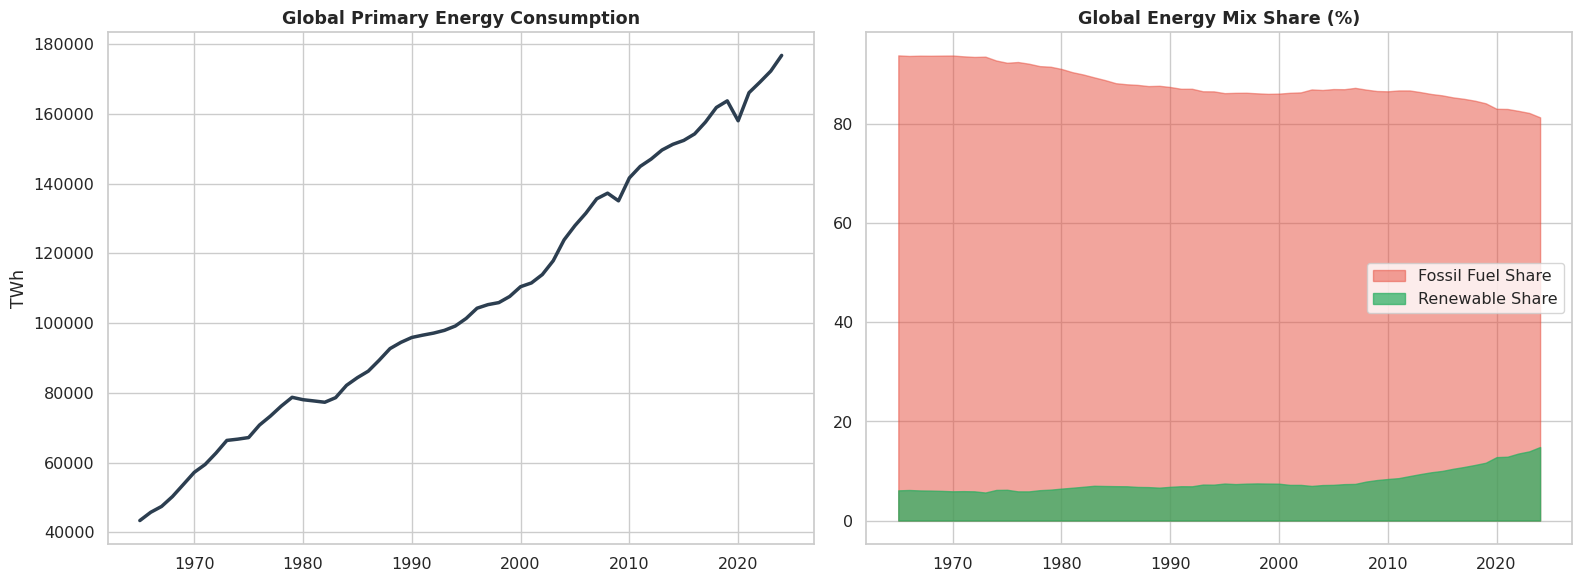

In [30]:
# ── 2. World Energy Trends ────────
world_data = df[df['country'] == 'World'].dropna(subset=['primary_energy_consumption'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Consumption over time
ax1.plot(world_data['year'], world_data['primary_energy_consumption'], color=COUNTRY_COLORS['World'], lw=2.5)
ax1.set_title('Global Primary Energy Consumption', fontweight='bold')
ax1.set_ylabel('TWh')

# Share of mix
ax2.fill_between(world_data['year'], world_data['fossil_share_energy'], color='#E74C3C', alpha=0.5, label='Fossil Fuel Share')
ax2.fill_between(world_data['year'], world_data['renewables_share_energy'], color='#27AE60', alpha=0.7, label='Renewable Share')
ax2.set_title('Global Energy Mix Share (%)', fontweight='bold')
ax2.legend(loc='center right')

plt.tight_layout()
plt.show()

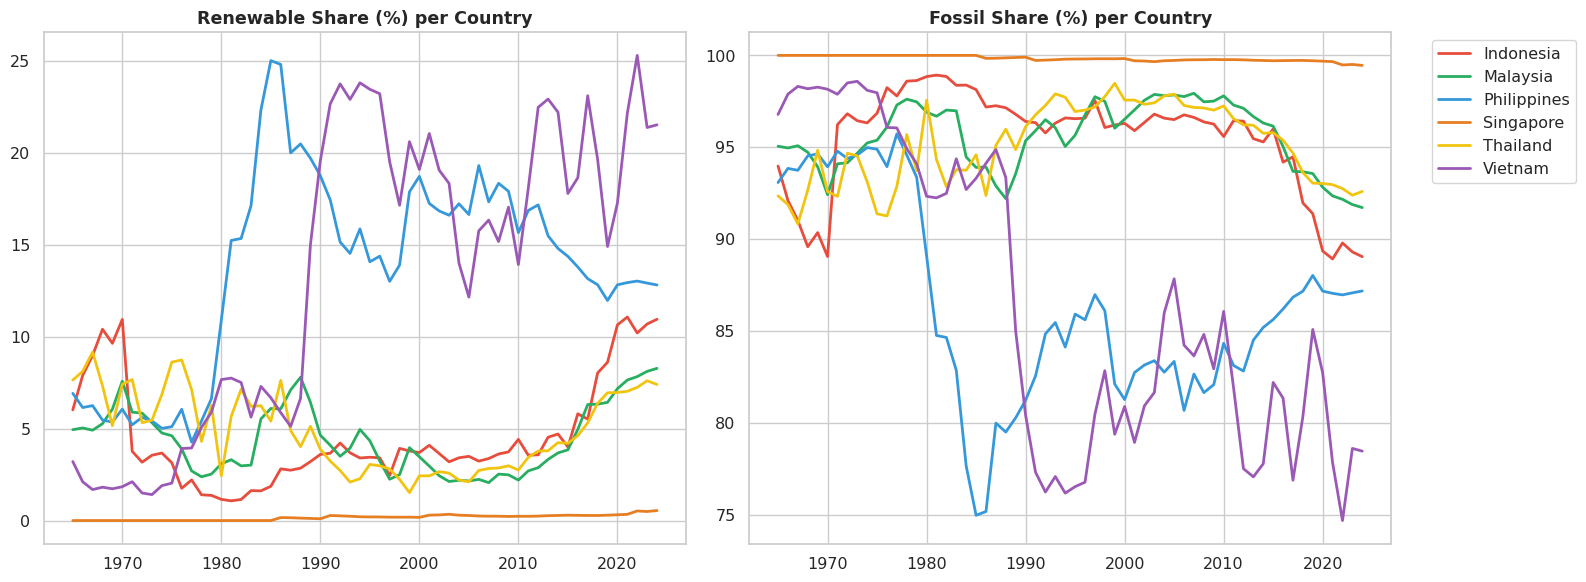

In [31]:
# ── 3. Southeast Asia: Renewable vs Fossil Shares ────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for country in SELECTED:
    c_df = df[df['country'] == country]
    ax1.plot(c_df['year'], c_df['renewables_share_energy'], label=country, color=COUNTRY_COLORS[country], lw=2)
    ax2.plot(c_df['year'], c_df['fossil_share_energy'], label=country, color=COUNTRY_COLORS[country], lw=2)

ax1.set_title('Renewable Share (%) per Country', fontweight='bold')
ax2.set_title('Fossil Share (%) per Country', fontweight='bold')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

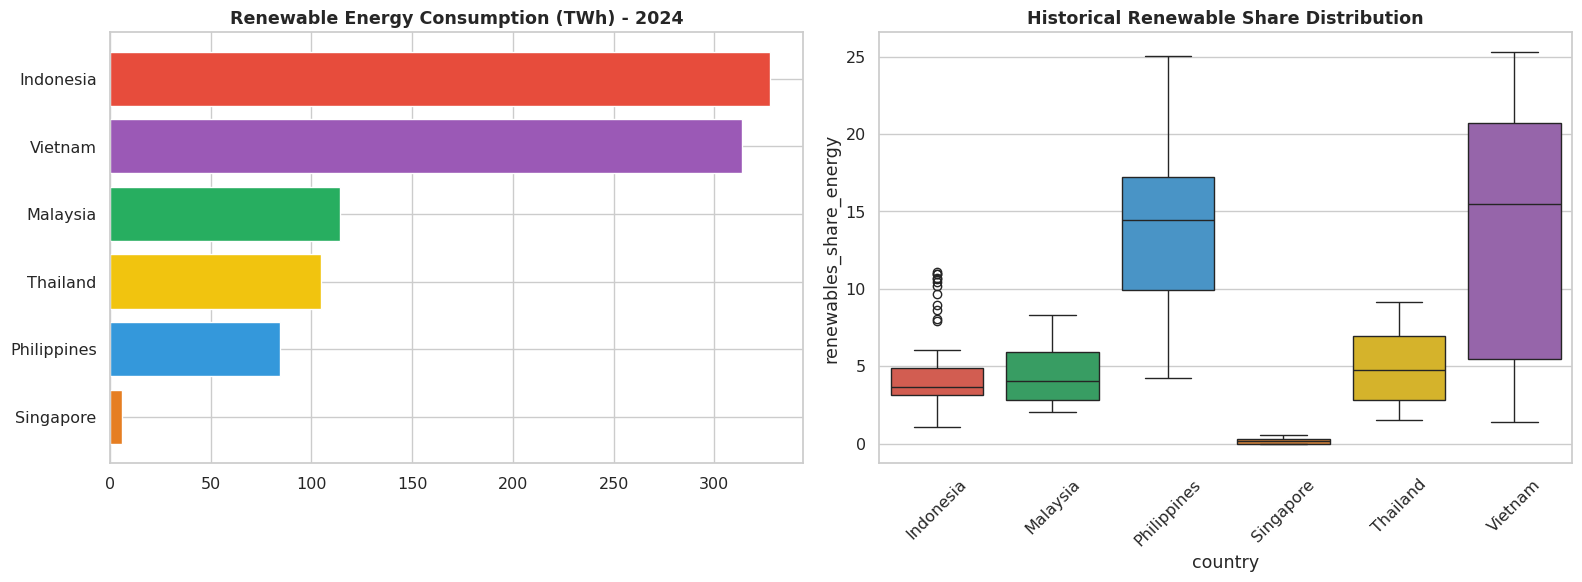

In [32]:
# ── 4. Distribution & Latest Rankings ─────────────
latest_yr = df['year'].max()
latest_data = df[(df['year'] == latest_yr) & (df['country'].isin(SELECTED))].sort_values('renewables_consumption')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart for latest renewable consumption
ax1.barh(latest_data['country'], latest_data['renewables_consumption'], color=[COUNTRY_COLORS[c] for c in latest_data['country']])
ax1.set_title(f'Renewable Energy Consumption (TWh) - {latest_yr}', fontweight='bold')

# Boxplot for historical renewable share distribution
sns.boxplot(data=df[df['country'].isin(SELECTED)], x='country', y='renewables_share_energy', palette=COUNTRY_COLORS, ax=ax2)
ax2.set_title('Historical Renewable Share Distribution', fontweight='bold')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

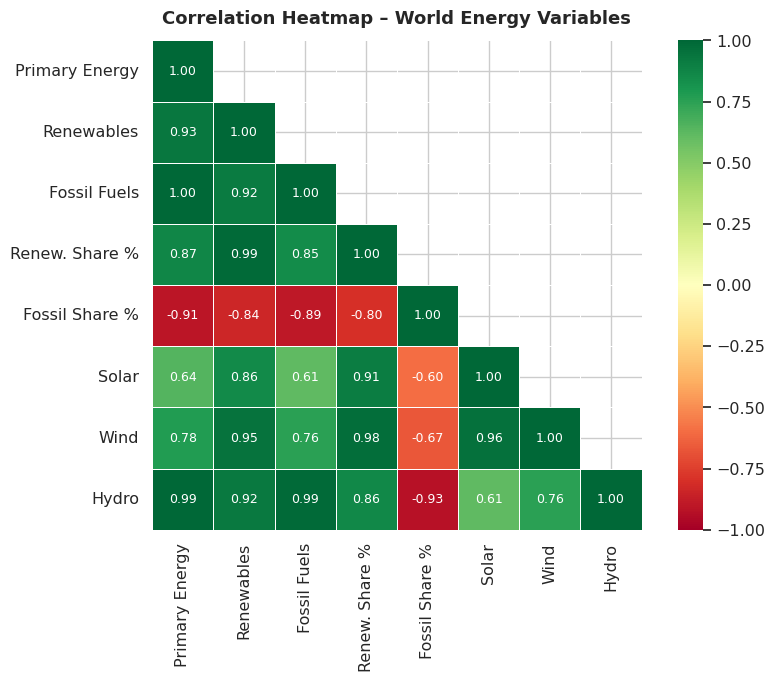

In [33]:
# ── 5. Correlation Heatmap (World only) ──────
heatmap_cols = [
    'primary_energy_consumption',
    'renewables_consumption',
    'fossil_fuel_consumption',
    'renewables_share_energy',
    'fossil_share_energy',
    'solar_consumption',
    'wind_consumption',
    'hydro_consumption',
]
world_hm = df[df['country'] == 'World'][heatmap_cols].dropna()
corr = world_hm.corr()

short_labels = {
    'primary_energy_consumption' : 'Primary Energy',
    'renewables_consumption'     : 'Renewables',
    'fossil_fuel_consumption'    : 'Fossil Fuels',
    'renewables_share_energy'    : 'Renew. Share %',
    'fossil_share_energy'        : 'Fossil Share %',
    'solar_consumption'          : 'Solar',
    'wind_consumption'           : 'Wind',
    'hydro_consumption'          : 'Hydro',
}
corr.index   = corr.index.map(short_labels)
corr.columns = corr.columns.map(short_labels)

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, linewidths=0.5,
            mask=mask, ax=ax, square=True,
            annot_kws={'size': 9})

ax.set_title('Correlation Heatmap – World Energy Variables',
             fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.show()

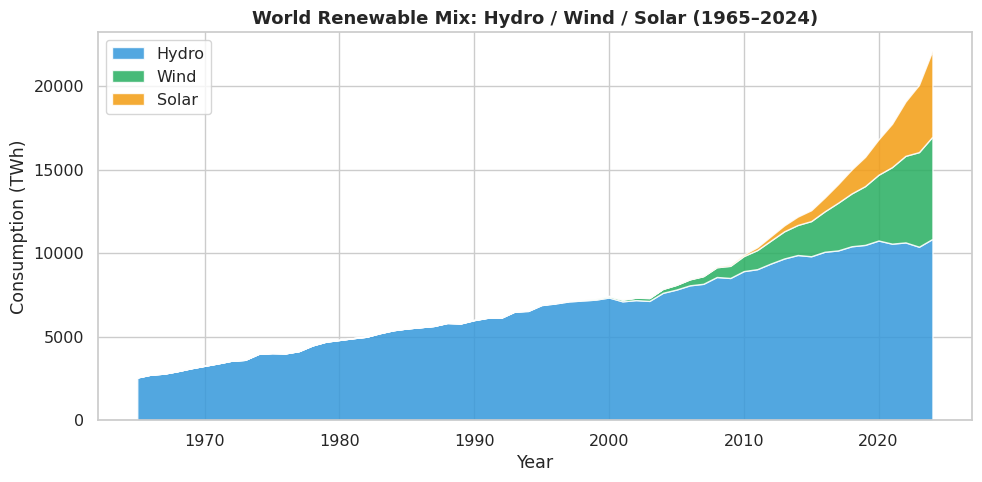

In [34]:
# ── 6. Renewable Mix Breakdown: Solar / Wind / Hydro (World) ──
mix_cols = ['solar_consumption', 'wind_consumption', 'hydro_consumption']
world_mix = df[df['country'] == 'World'][['year'] + mix_cols].dropna()

fig, ax = plt.subplots(figsize=(10, 5))
ax.stackplot(world_mix['year'],
             world_mix['hydro_consumption'],
             world_mix['wind_consumption'],
             world_mix['solar_consumption'],
             labels=['Hydro', 'Wind', 'Solar'],
             colors=['#3498DB', '#27AE60', '#F39C12'],
             alpha=0.85)

ax.set_title('World Renewable Mix: Hydro / Wind / Solar (1965–2024)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Consumption (TWh)')
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

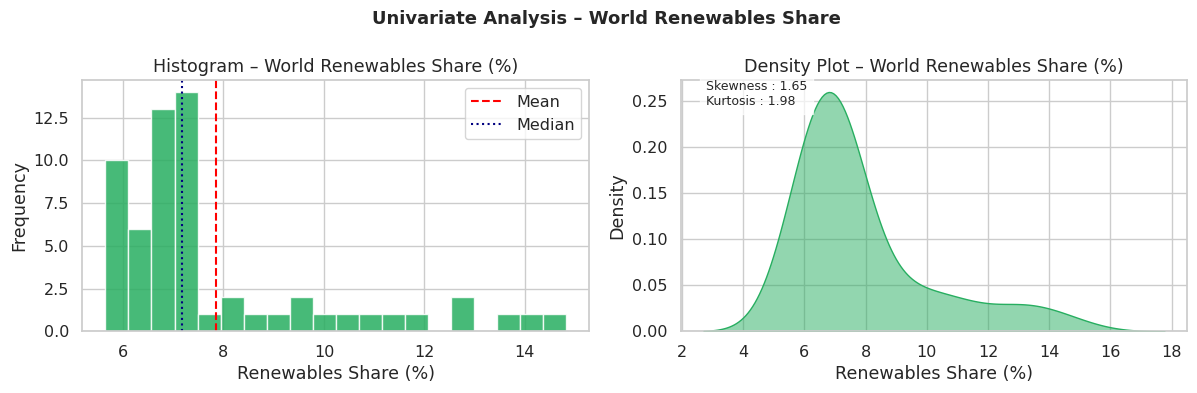

In [35]:
# ── 7. Univariate Analysis: World Renewables Share ──
world_u = df[df['country'] == 'World'].dropna(subset=['renewables_share_energy'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(world_u['renewables_share_energy'], bins=20,
             color='#27AE60', edgecolor='white', alpha=0.85)
axes[0].axvline(world_u['renewables_share_energy'].mean(),
                color='red', linestyle='--', linewidth=1.5, label='Mean')
axes[0].axvline(world_u['renewables_share_energy'].median(),
                color='navy', linestyle=':', linewidth=1.5, label='Median')
axes[0].set_title('Histogram – World Renewables Share (%)')
axes[0].set_xlabel('Renewables Share (%)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Density plot (KDE)
sns.kdeplot(world_u['renewables_share_energy'],
            color='#27AE60', fill=True, alpha=0.5, ax=axes[1])
axes[1].set_title('Density Plot – World Renewables Share (%)')
axes[1].set_xlabel('Renewables Share (%)')
axes[1].set_ylabel('Density')

skew_val = world_u['renewables_share_energy'].skew()
kurt_val = world_u['renewables_share_energy'].kurtosis()
axes[1].text(0.05, 0.90, f'Skewness : {skew_val:.2f}\nKurtosis : {kurt_val:.2f}',
             transform=axes[1].transAxes, fontsize=9,
             bbox=dict(facecolor='white', alpha=0.7))

plt.suptitle('Univariate Analysis – World Renewables Share', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [36]:
# ── 8. Per-Country Summary (Latest Available Year) ──
print()
print("=" * 65)
print("  PER-COUNTRY SUMMARY – Most Recent Available Year")
print("=" * 65)

summary_cols = [
    'country', 'year',
    'primary_energy_consumption',
    'renewables_share_energy',
    'fossil_share_energy',
    'renewables_consumption',
    'fossil_fuel_consumption'
]

latest_all = []
for c in COUNTRIES:
    cdf = df[df['country'] == c].dropna(subset=['renewables_share_energy'])
    if not cdf.empty:
        latest_all.append(cdf.iloc[-1][summary_cols])

summary_df = pd.DataFrame(latest_all).set_index('country')
summary_df['year'] = summary_df['year'].astype(int)
summary_df = summary_df.round(2)

print(summary_df.to_string())
print("=" * 65)


  PER-COUNTRY SUMMARY – Most Recent Available Year
             year  primary_energy_consumption  renewables_share_energy  fossil_share_energy  renewables_consumption  fossil_fuel_consumption
country                                                                                                                                     
World        2024                   176737.09                    14.82                81.26                25979.02                142420.89
Indonesia    2024                     2984.73                    10.95                89.05                  327.60                  2663.05
Malaysia     2024                     1381.98                     8.28                91.72                  113.98                  1262.25
Philippines  2024                      652.56                    12.82                87.18                   84.18                   572.52
Singapore    2024                     1053.92                     0.55                99.46           